<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Stylized-Facts-Report/Stylized_Facts_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
from scipy.stats import norm

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.graphics.tsaplots as tsaplots
from statsmodels.api import qqplot

In [13]:
tickers = ['NFLX']

data = yf.download(tickers, start = '2015-01-01', end = '2026-01-01')['Close']
returns = data.pct_change().dropna()

returns.head()

/tmp/ipython-input-2661407662.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = '2015-01-01', end = '2026-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,NFLX
Date,
2015-01-05,-0.050897
2015-01-06,-0.017121
2015-01-07,0.005192
2015-01-08,0.022188
2015-01-09,-0.015458


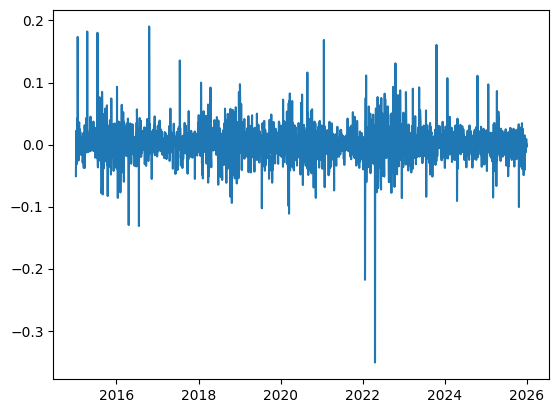

In [14]:
plt.plot(returns.index, returns)
plt.show()

Mandelbrot's Observation (Look for)

In [15]:
squared_returns = returns**2
squared_returns.head()

Ticker,NFLX
Date,
2015-01-05,0.002591
2015-01-06,0.000293
2015-01-07,0.000027
2015-01-08,0.000492
2015-01-09,0.000239


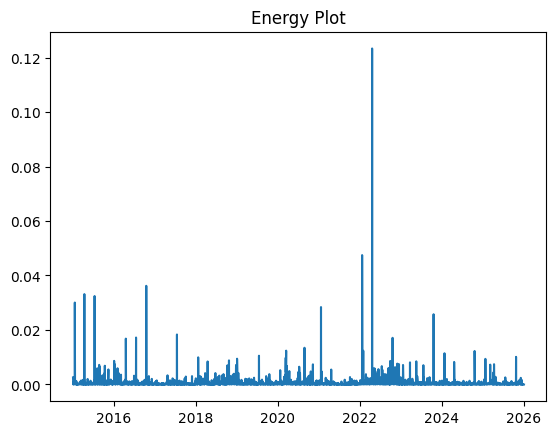

In [16]:
plt.title('Energy Plot')
plt.plot(squared_returns.index, squared_returns)
plt.show()

Memory Test (Autocorrelation)

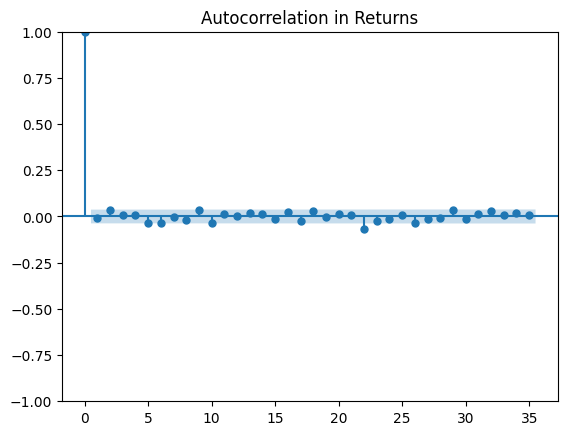

In [17]:
tsaplots.plot_acf(returns,
                  title = 'Autocorrelation in Returns');

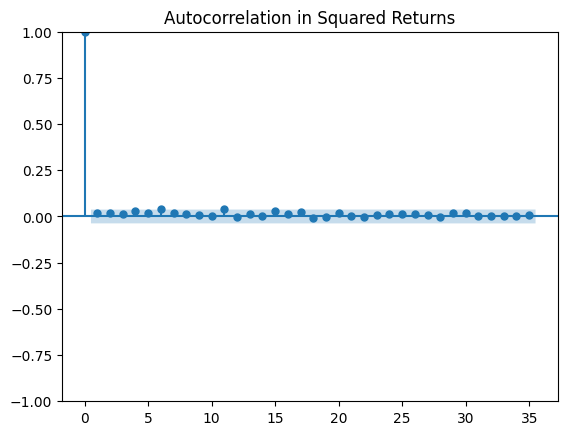

In [18]:
tsaplots.plot_acf(squared_returns,
                  title = 'Autocorrelation in Squared Returns');

Observation,Market Meaning
1. All bars inside blue area,"Random Walk: The market has fully ""priced in"" the news. No predictable pattern exists."
2. Strong Positive Lag 1,"Momentum: If the stock went up yesterday, it's likely to go up today (Under-reaction to news)."
3. Strong Negative Lag 1,"Mean Reversion: A ""bounce"" or ""correction."" If it went up yesterday, it's likely to pull back today (Over-reaction)."
4. "Spikes at Lag 5, 10, etc.",Seasonality: There is a weekly or bi-weekly pattern (common in high-frequency trading or institutional rebalancing).

# **The Autocorrelation Plots imply that the market is efficient to long-term returns. Prices beyond 15-20 days away from today don't have impact on today's price.**

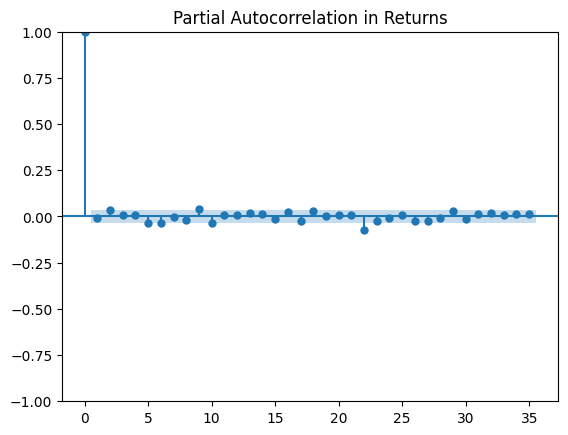

In [19]:
tsaplots.plot_pacf(returns,
                  title = 'Partial Autocorrelation in Returns');

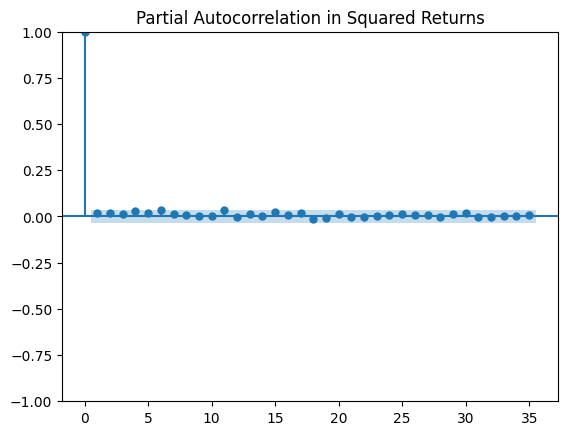

In [20]:
tsaplots.plot_pacf(squared_returns,
                  title = 'Partial Autocorrelation in Squared Returns');

<Axes: ylabel='Count'>

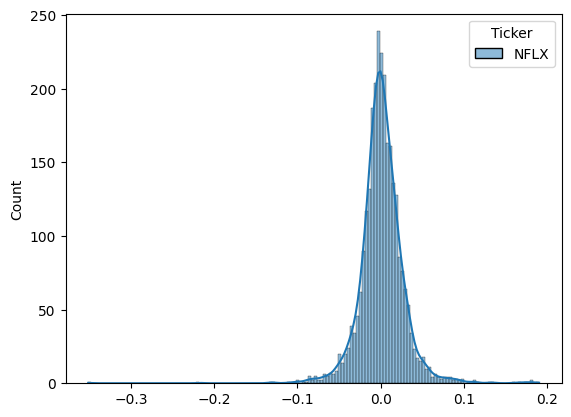

In [21]:
sns.histplot(returns, kde = True)

The Peak of the data is higher than the curve (Peakedness), and the Edges (Tails) are fatter.

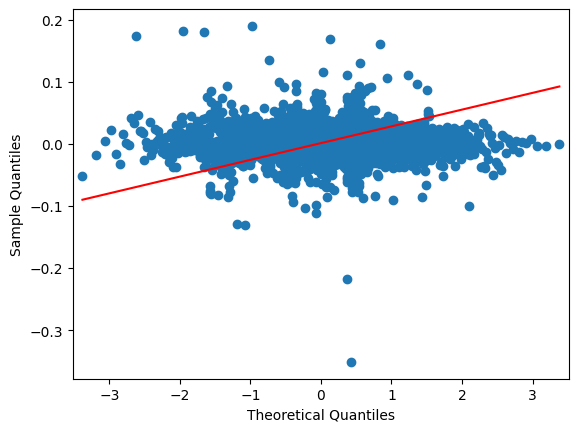

In [24]:
qqplot(returns, line='s');

Returns are not Normal according to Q-Q Plot

In [25]:
returns.kurtosis()

,0
Ticker,
NFLX,17.376855


In [27]:
weekly_data = data.resample('W').last().pct_change().dropna()
weekly_data.head()

Ticker,NFLX
Date,
2015-01-11,-0.056313
2015-01-18,0.024446
2015-01-25,0.296793
2015-02-01,0.009921
2015-02-08,0.005794


In [28]:
weekly_data.kurtosis()

,0
Ticker,
NFLX,5.552636


In [30]:
monthly_data = data.resample('M').last().pct_change().dropna()
monthly_data.head()

/tmp/ipython-input-2786353580.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = data.resample('M').last().pct_change().dropna()


Ticker,NFLX
Date,
2015-02-28,0.074943
2015-03-31,-0.122592
2015-04-30,0.335525
2015-05-31,0.121402
2015-06-30,0.052687


In [31]:
monthly_data.kurtosis()

,0
Ticker,
NFLX,3.044527


# Risk models work better on longer timeframes.

In [37]:
# Calculate "Lagged" Correlation

returns['NFLX'].corr(squared_returns['NFLX'])

np.float64(-0.05371400557837509)

In [38]:
tickers = ['NFLX', '^VIX']

data = yf.download(tickers, start = '2015-01-01', end = '2026-01-01')['Close']
data.head()

/tmp/ipython-input-2733605911.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = '2015-01-01', end = '2026-01-01')['Close']
[*********************100%***********************]  2 of 2 completed


Ticker,NFLX,^VIX
Date,,
2015-01-02,4.984857,17.790001
2015-01-05,4.731143,19.920000
2015-01-06,4.650143,21.120001
2015-01-07,4.674286,19.309999
2015-01-08,4.778000,17.010000


In [40]:
changes = data.pct_change().dropna()
changes.head()

Ticker,NFLX,^VIX
Date,,
2015-01-05,-0.050897,0.119730
2015-01-06,-0.017121,0.060241
2015-01-07,0.005192,-0.085701
2015-01-08,0.022188,-0.119109
2015-01-09,-0.015458,0.031746


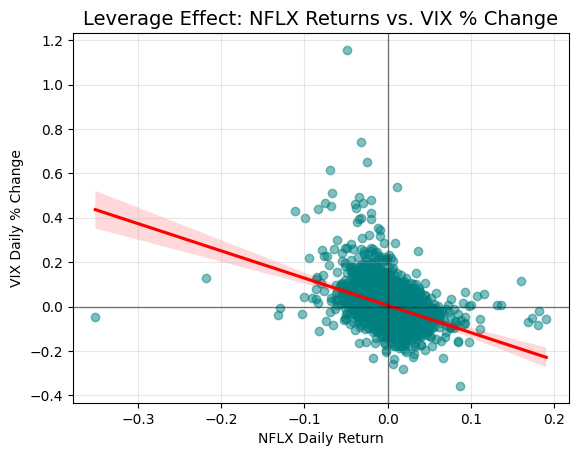

In [44]:
sns.regplot(x=changes['NFLX'], y=changes['^VIX'],
            scatter_kws={'alpha':0.5, 'color':'teal'},
            line_kws={'color':'red'})

plt.axhline(0, color='black', lw=1, alpha=0.5)
plt.axvline(0, color='black', lw=1, alpha=0.5)
plt.title('Leverage Effect: NFLX Returns vs. VIX % Change', fontsize=14)
plt.xlabel('NFLX Daily Return')
plt.ylabel('VIX Daily % Change')
plt.grid(True, alpha=0.3)
plt.show()

When Returns are Negative, Volatility explodes. When Returns are Positive, Volatility often drops or stays flat.

In [48]:
tickers = ['NFLX']

data = yf.download(tickers, start = '2015-01-01', end = '2026-01-01')[['Close', 'Volume']]
data.head()

/tmp/ipython-input-115381361.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = '2015-01-01', end = '2026-01-01')[['Close', 'Volume']]
[*********************100%***********************]  1 of 1 completed


Price,Close,Volume
Ticker,NFLX,NFLX
Date,,
2015-01-02,4.984857,134750000
2015-01-05,4.731143,181650000
2015-01-06,4.650143,160377000
2015-01-07,4.674286,98497000
2015-01-08,4.778000,96019000


In [59]:
absolute_returns = data['Close'].pct_change().abs()
absolute_returns.head()

Ticker,NFLX
Date,
2015-01-02,NaN
2015-01-05,0.050897
2015-01-06,0.017121
2015-01-07,0.005192
2015-01-08,0.022188


In [60]:
volume = data['Volume']
volume.head()

Ticker,NFLX
Date,
2015-01-02,134750000
2015-01-05,181650000
2015-01-06,160377000
2015-01-07,98497000
2015-01-08,96019000


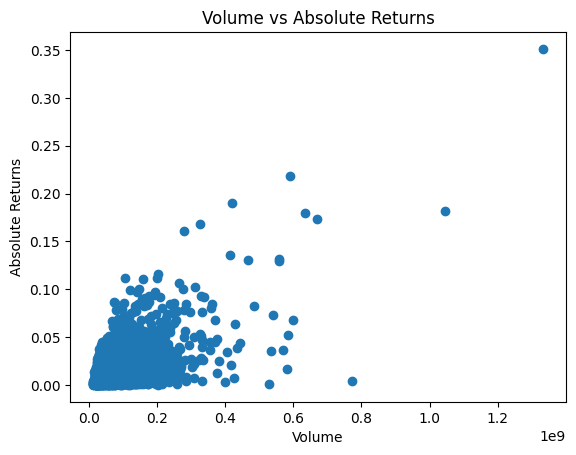

In [64]:
plt.title("Volume vs Absolute Returns")
plt.scatter(volume, absolute_returns)
plt.xlabel('Volume')
plt.ylabel('Absolute Returns')
plt.show()

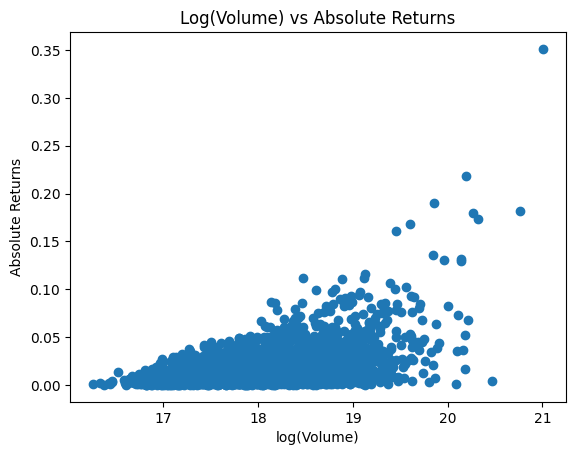

In [65]:
plt.title("Log(Volume) vs Absolute Returns")
plt.scatter(np.log(volume), absolute_returns)
plt.xlabel('log(Volume)')
plt.ylabel('Absolute Returns')
plt.show()